In [1]:
import os

os.chdir("/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/Week_6")
print(os.getcwd())

/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/Week_6


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

print("Libraries Imported")

Libraries Imported


In [3]:
DATA_PATH = "src/data/processed/diabetes_clean.csv"
LOG_DIR = "src/logs"

os.makedirs(LOG_DIR, exist_ok=True)

print("Data Path", DATA_PATH)
print("Log Directory",LOG_DIR)

Data Path src/data/processed/diabetes_clean.csv
Log Directory src/logs


In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

df.head()

print("Loaded Cleaned Data")

Dataset Shape: (768, 14)
Loaded Cleaned Data


In [5]:
print("Dataset information")

df.info()

Dataset information
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
 9   Glucose_missing           768 non-null    int64  
 10  BloodPressure_missing     768 non-null    int64  
 11  SkinThickness_missing     768 non-null    int64  
 12  Insulin_missing           768 non-null    int64  
 13  BMI_missing               768 non-null    int64  
dtypes

In [6]:
print("Missing values summary")
df.isnull().sum()

Missing values summary


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_missing             0
BloodPressure_missing       0
SkinThickness_missing       0
Insulin_missing             0
BMI_missing                 0
dtype: int64

In [7]:
print("Statistical Summary")
df.describe()

Statistical Summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_missing,BloodPressure_missing,SkinThickness_missing,Insulin_missing,BMI_missing
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.0,768.0,768.000000,768.000000,768.0
mean,3.837240,121.656250,72.358073,28.866536,124.691081,32.393359,0.458914,33.199870,0.348958,0.0,0.0,0.295573,0.486979,0.0
std,3.344157,30.438286,11.697097,7.442353,7.913595,6.667471,0.285596,11.628404,0.476951,0.0,0.0,0.456597,0.500156,0.0
min,0.000000,44.000000,40.000000,14.500000,112.875000,18.200000,0.078000,21.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000,0.0,0.0,1.000000,1.000000,0.0
max,13.500000,199.000000,104.000000,42.500000,135.875000,50.250000,1.200000,66.500000,1.000000,0.0,0.0,1.000000,1.000000,0.0


Missing values heatmap


/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/.venv/lib/python3.12/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/.venv/lib/python3.12/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Figure size 100x100 with 0 Axes>

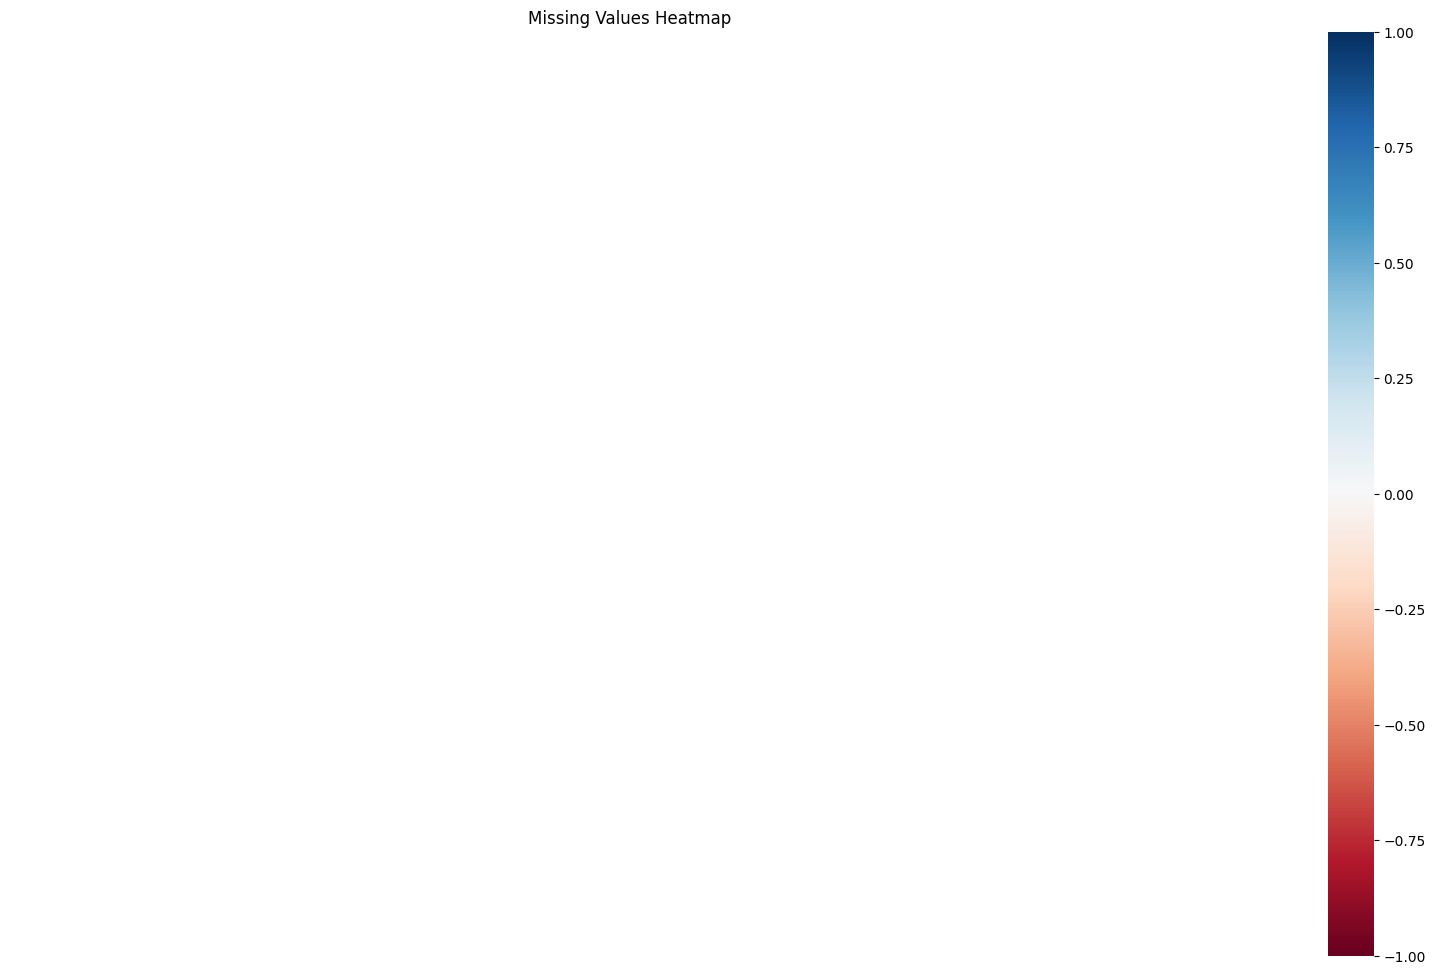

In [8]:
print("Missing values heatmap")

plt.figure(figsize=(1,1))
msno.heatmap(df)
plt.title("Missing Values Heatmap")

plt.savefig(f"{LOG_DIR}/missing_values_heatmap.png")
plt.show()

Correlation Matrix


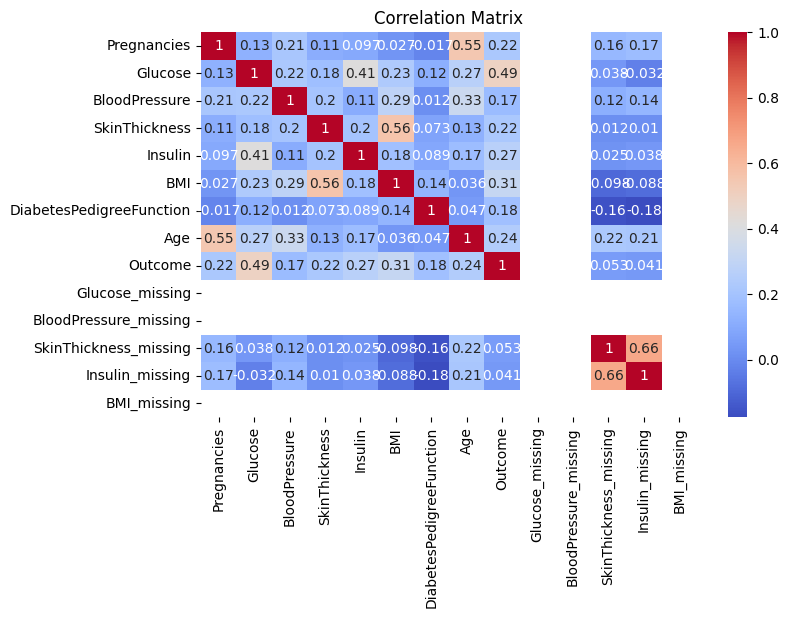

In [9]:
print("Correlation Matrix")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.savefig(f"{LOG_DIR}/correlation_matrix.png")
plt.show()

Target Distribution


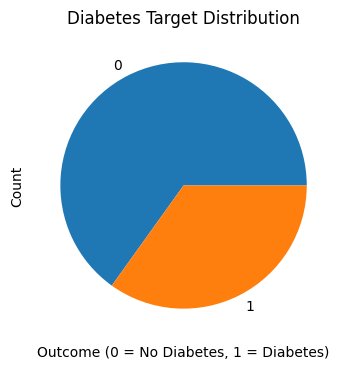

In [10]:

print("Target Distribution")
plt.figure(figsize=(5,4))

df["Outcome"].value_counts().plot(kind="pie")

plt.title("Diabetes Target Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")

plt.savefig(f"{LOG_DIR}/target_distribution.png")
plt.show()

Feature Distributions
SkinThickness
29.0    244
42.5     48
14.5     39
32.0     31
30.0     27
Name: count, dtype: int64


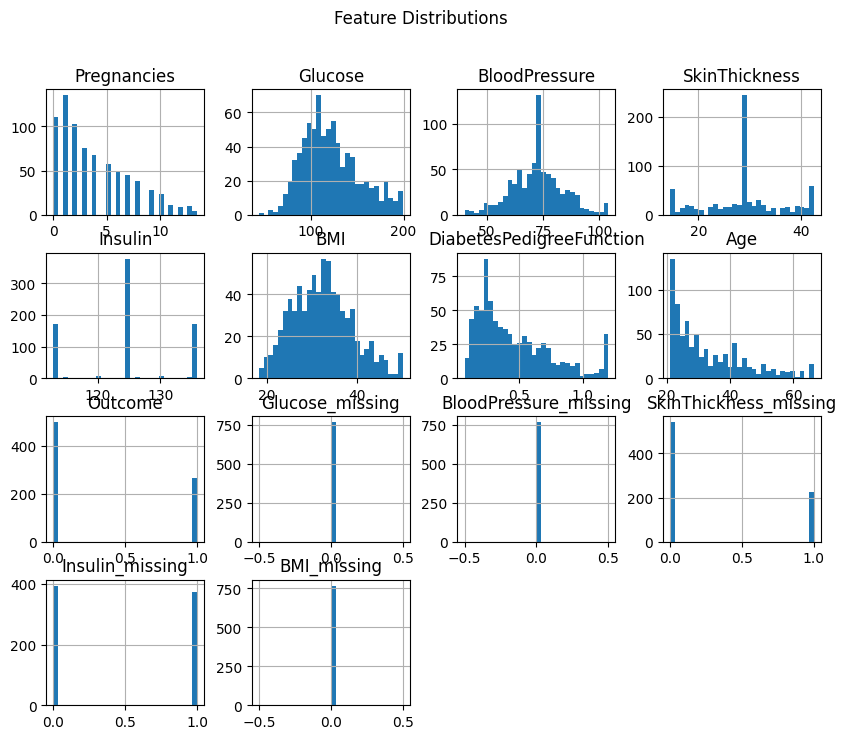

In [11]:
print("Feature Distributions")

numeric_cols = df.select_dtypes(include="number").columns
print(df["SkinThickness"].value_counts().head())

df[numeric_cols].hist(figsize=(10,8), bins=30)

plt.suptitle("Feature Distributions")

plt.savefig(f"{LOG_DIR}/feature_distributions.png")
plt.show()